In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dat = pd.read_csv('data/airgradient.csv')
dat['datetime'] = pd.to_datetime(dat['UTC Date/Time'])

In [3]:
dat.columns

Index(['Location ID', 'Location Name', 'Location Group', 'Location Type',
       'Sensor ID', 'Place Open', 'Local Date/Time', 'UTC Date/Time',
       '# of aggregated records', 'PM2.5 (μg/m³) raw',
       'PM2.5 (μg/m³) corrected', '0.3μm particle count', 'CO2 (ppm) raw',
       'CO2 (ppm) corrected', 'Temperature (°C) raw',
       'Temperature (°C) corrected', 'Heat Index (°C)', 'Humidity (%) raw',
       'Humidity (%) corrected', 'TVOC (ppb)', 'TVOC index', 'NOX index',
       'PM1 (μg/m³)', 'PM10 (μg/m³)', 'datetime'],
      dtype='object')

In [4]:
vars = [
    'PM2.5 (μg/m³) corrected',
    '0.3μm particle count',
    'CO2 (ppm) corrected',
    'Temperature (°C) corrected',
    'Humidity (%) corrected',
    'TVOC (ppb)',
    'PM1 (μg/m³)',
    'PM10 (μg/m³)',
]

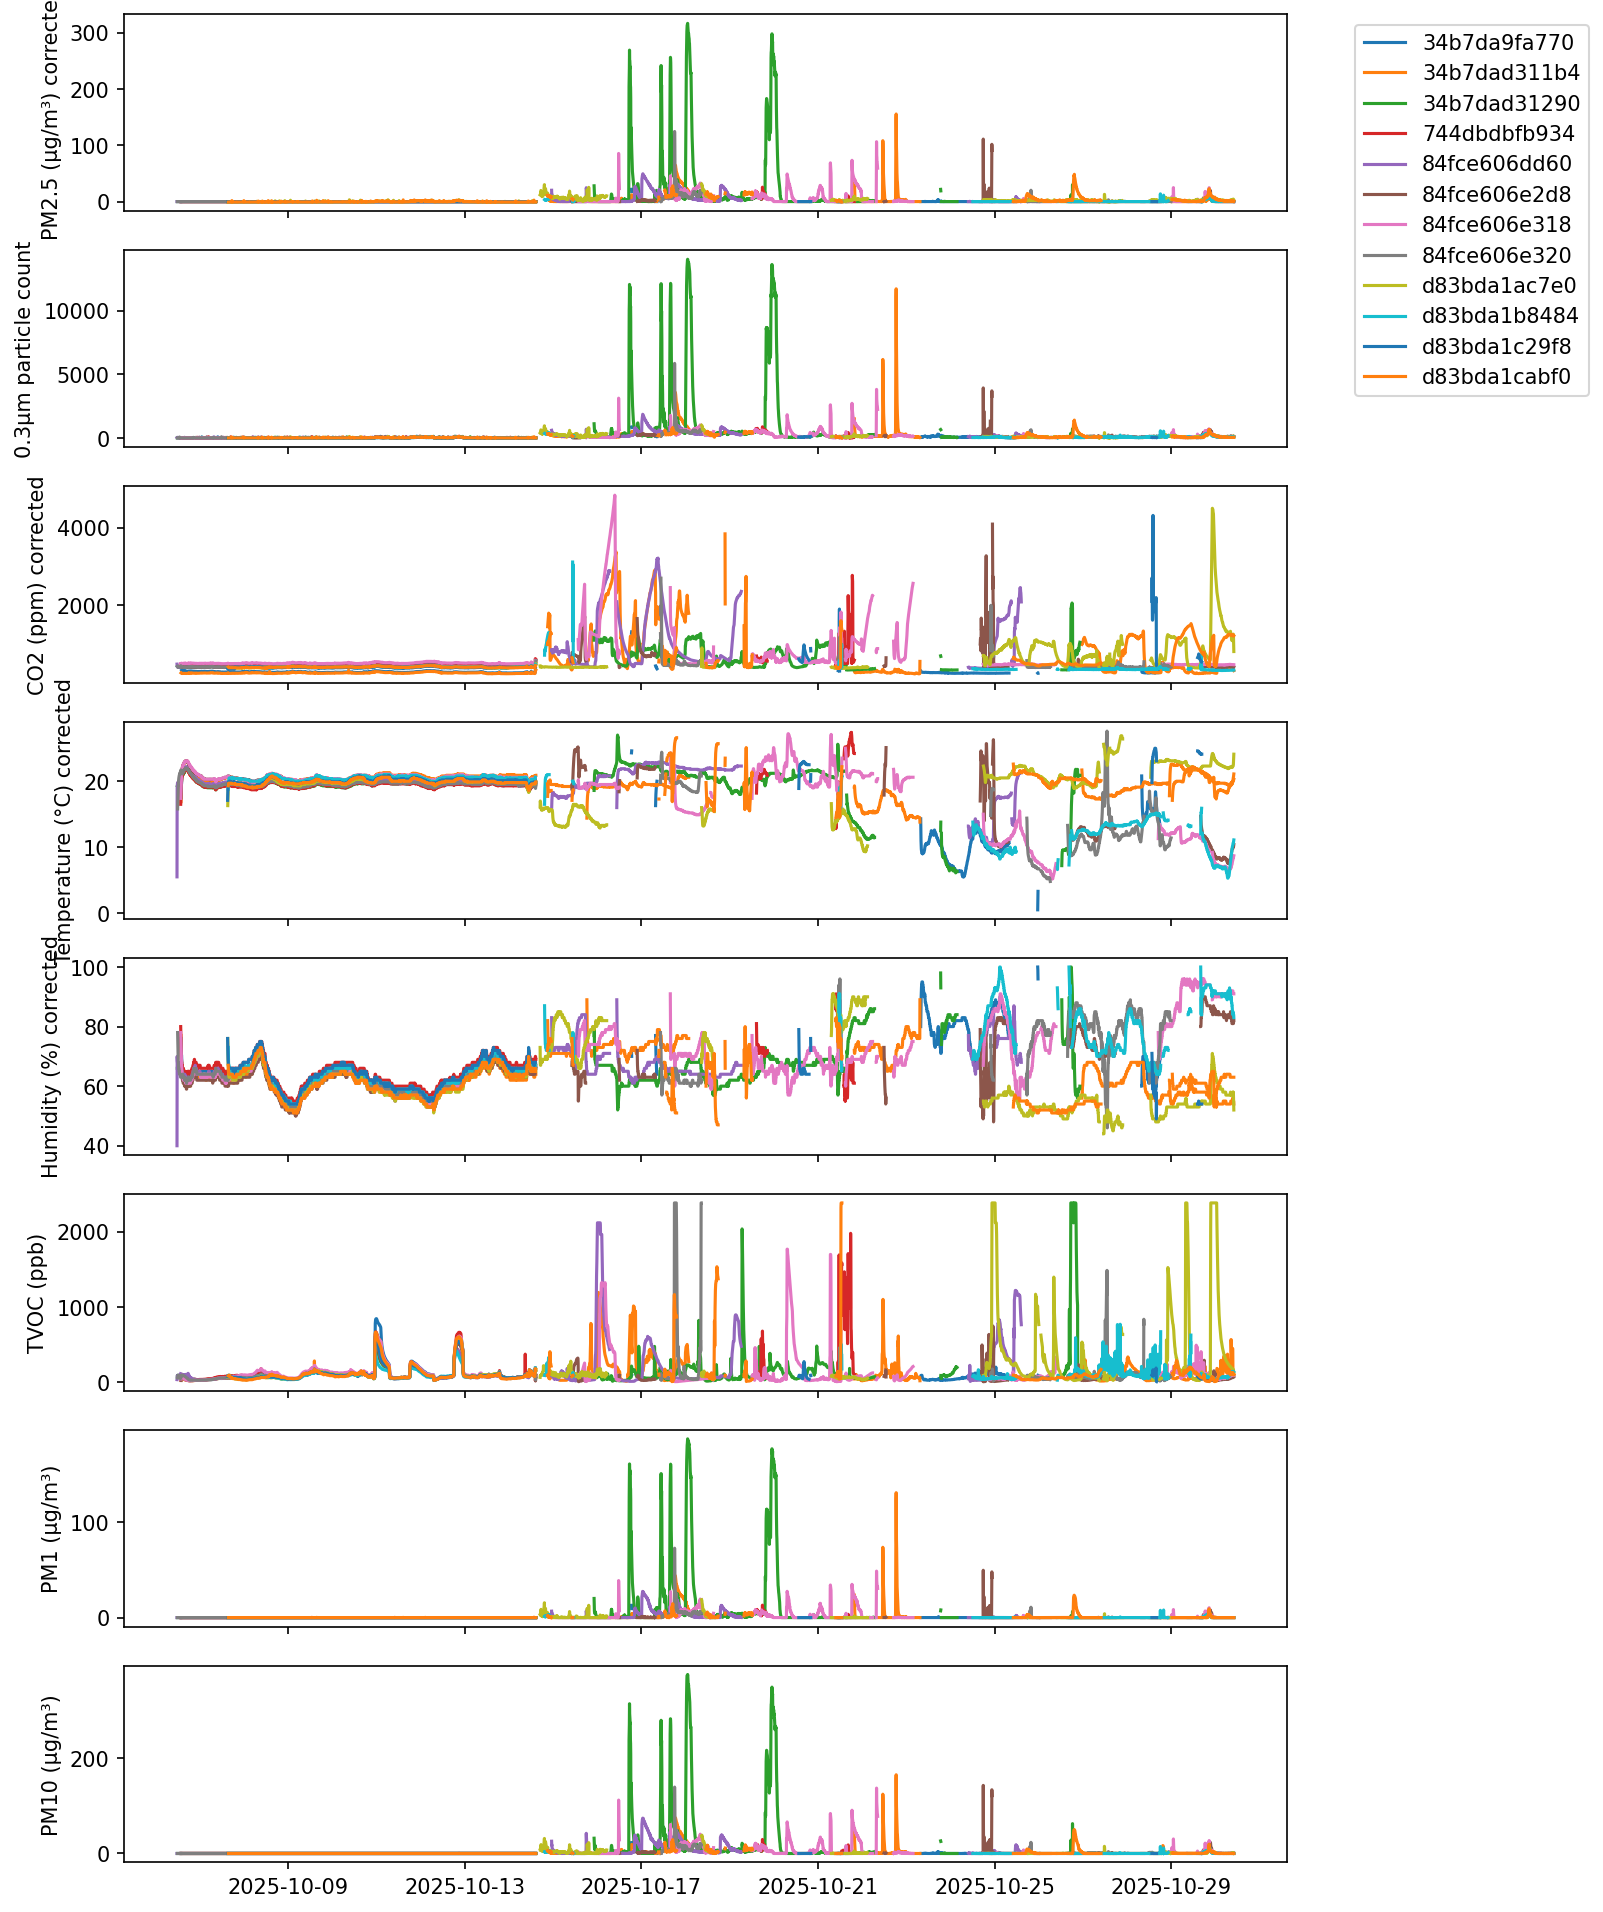

In [5]:
fig, axs = plt.subplots(nrows=len(vars), figsize=(10, 2*len(vars)), sharex=True)
for i, g in dat.groupby('Location Name'):
    g = g.sort_values('datetime').reset_index(drop=True)
    time_diff = g['datetime'].diff()
    mask = time_diff > pd.Timedelta(minutes=5)

    for j, var in enumerate(vars):
        plot_data = g[var].copy()
        plot_data[mask] = float('nan')

        axs[j].plot(g['datetime'], plot_data, label=i)

        axs[j].set_ylabel(var)
        
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## Rough Calibration

Linear fit between all sensors across baseline period.

/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


Could not fit for 34b7dad311b4 and variable PM2.5 (μg/m³) corrected: SVD did not converge in Linear Least Squares
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Could not fit for 34b7dad31290 and variable PM2.5 (μg/m³) corrected: SVD did not converge in Linear Least Squares
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Coul

/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
/home/oscar/.venvs/py3/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


Could not fit for 34b7dad311b4 and variable PM1 (μg/m³): SVD did not converge in Linear Least Squares
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Could not fit for 34b7dad31290 and variable PM1 (μg/m³): SVD did not converge in Linear Least Squares
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Could not fit for 84fce606e3

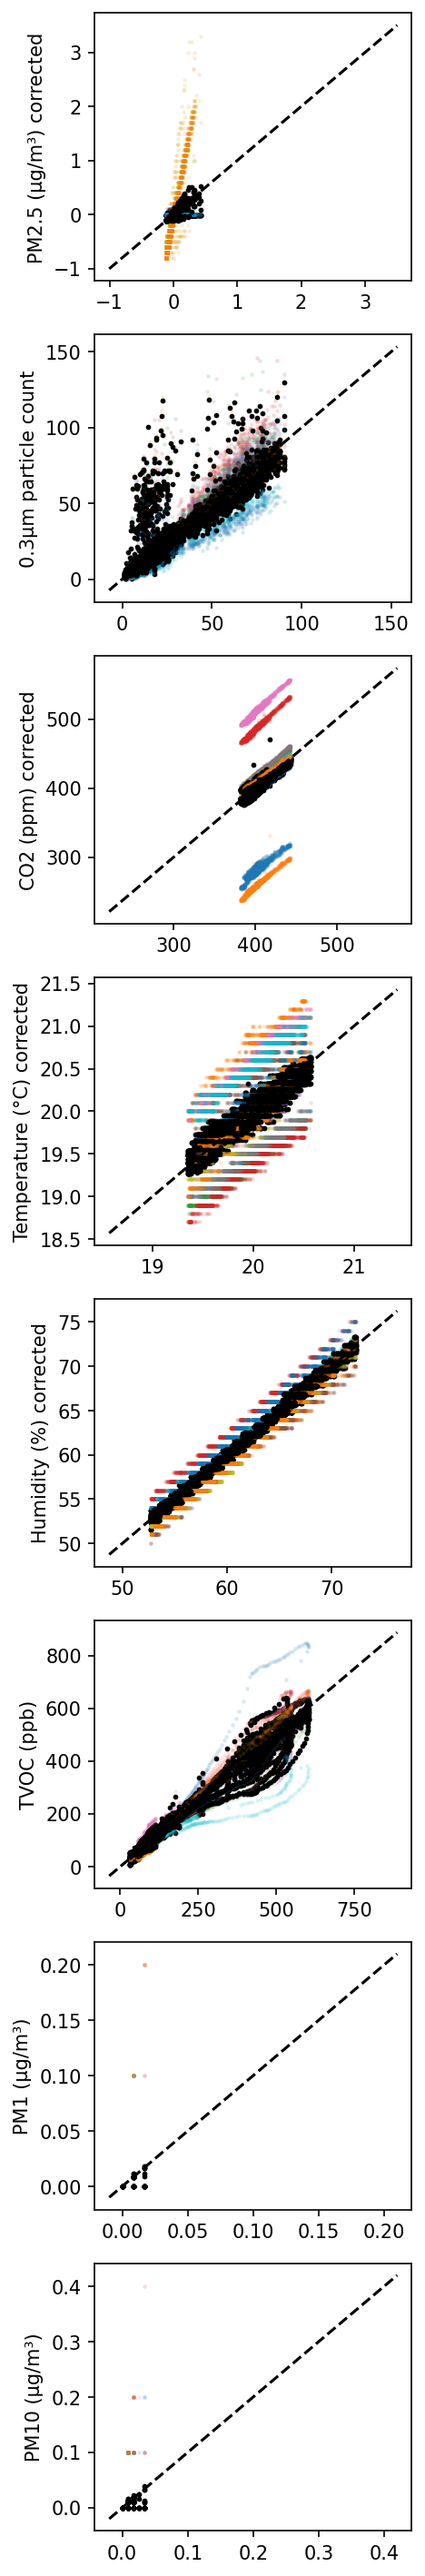

In [6]:
baseline_start = pd.to_datetime('2025-10-08 00:01:00', utc=True)
baseline_end = pd.to_datetime('2025-10-13 23:59:59', utc=True)

cal = dat.copy()

sub = dat[(dat['datetime'] >= baseline_start) & (dat['datetime'] <= baseline_end)]
sub.set_index('datetime', inplace=True)

ref = sub.groupby(level=0).aggregate({var: 'mean' for var in vars})

fig, axs = plt.subplots(nrows=len(vars), figsize=(3, 3*len(vars)))

for v, ax in zip(vars, axs):
    vsub = sub
    for g_name, g in vsub.groupby('Location Name'):
        g = g[v]
        rg = ref.loc[g.index, v]
    
        pts = ax.scatter(rg, g, s=2, alpha=0.1, edgecolor=None)
        ax.set_ylabel(v)
        
        try:
            p = np.polyfit(g, rg, 1)
            
            cor = np.polyval(p, g)
            ax.scatter(rg, cor, s=3, color='k', alpha=1)
            
            cal.loc[cal['Location Name']==g_name,v] = np.polyval(p, cal.loc[cal['Location Name']==g_name,v])
            
        except Exception as e:
            print(f"Could not fit for {g_name} and variable {v}: {e}")
            p = [1, 0]

for ax in axs:
    lolim = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hilim = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lolim, hilim], [lolim, hilim], color='k', linestyle='--')

    # cal[v] = (cal[v] - p[1]) / p[0]

#     for j, var in enumerate(vars):
#         plot_data = g_sub[var].copy()
#         plot_data[mask] = float('nan')

#         axs[j].plot(g_sub['datetime'], plot_data, label=i)

#         axs[j].set_ylabel(var)
        
        
# axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

(np.float64(20374.999988425927), np.float64(20391.413194444445))

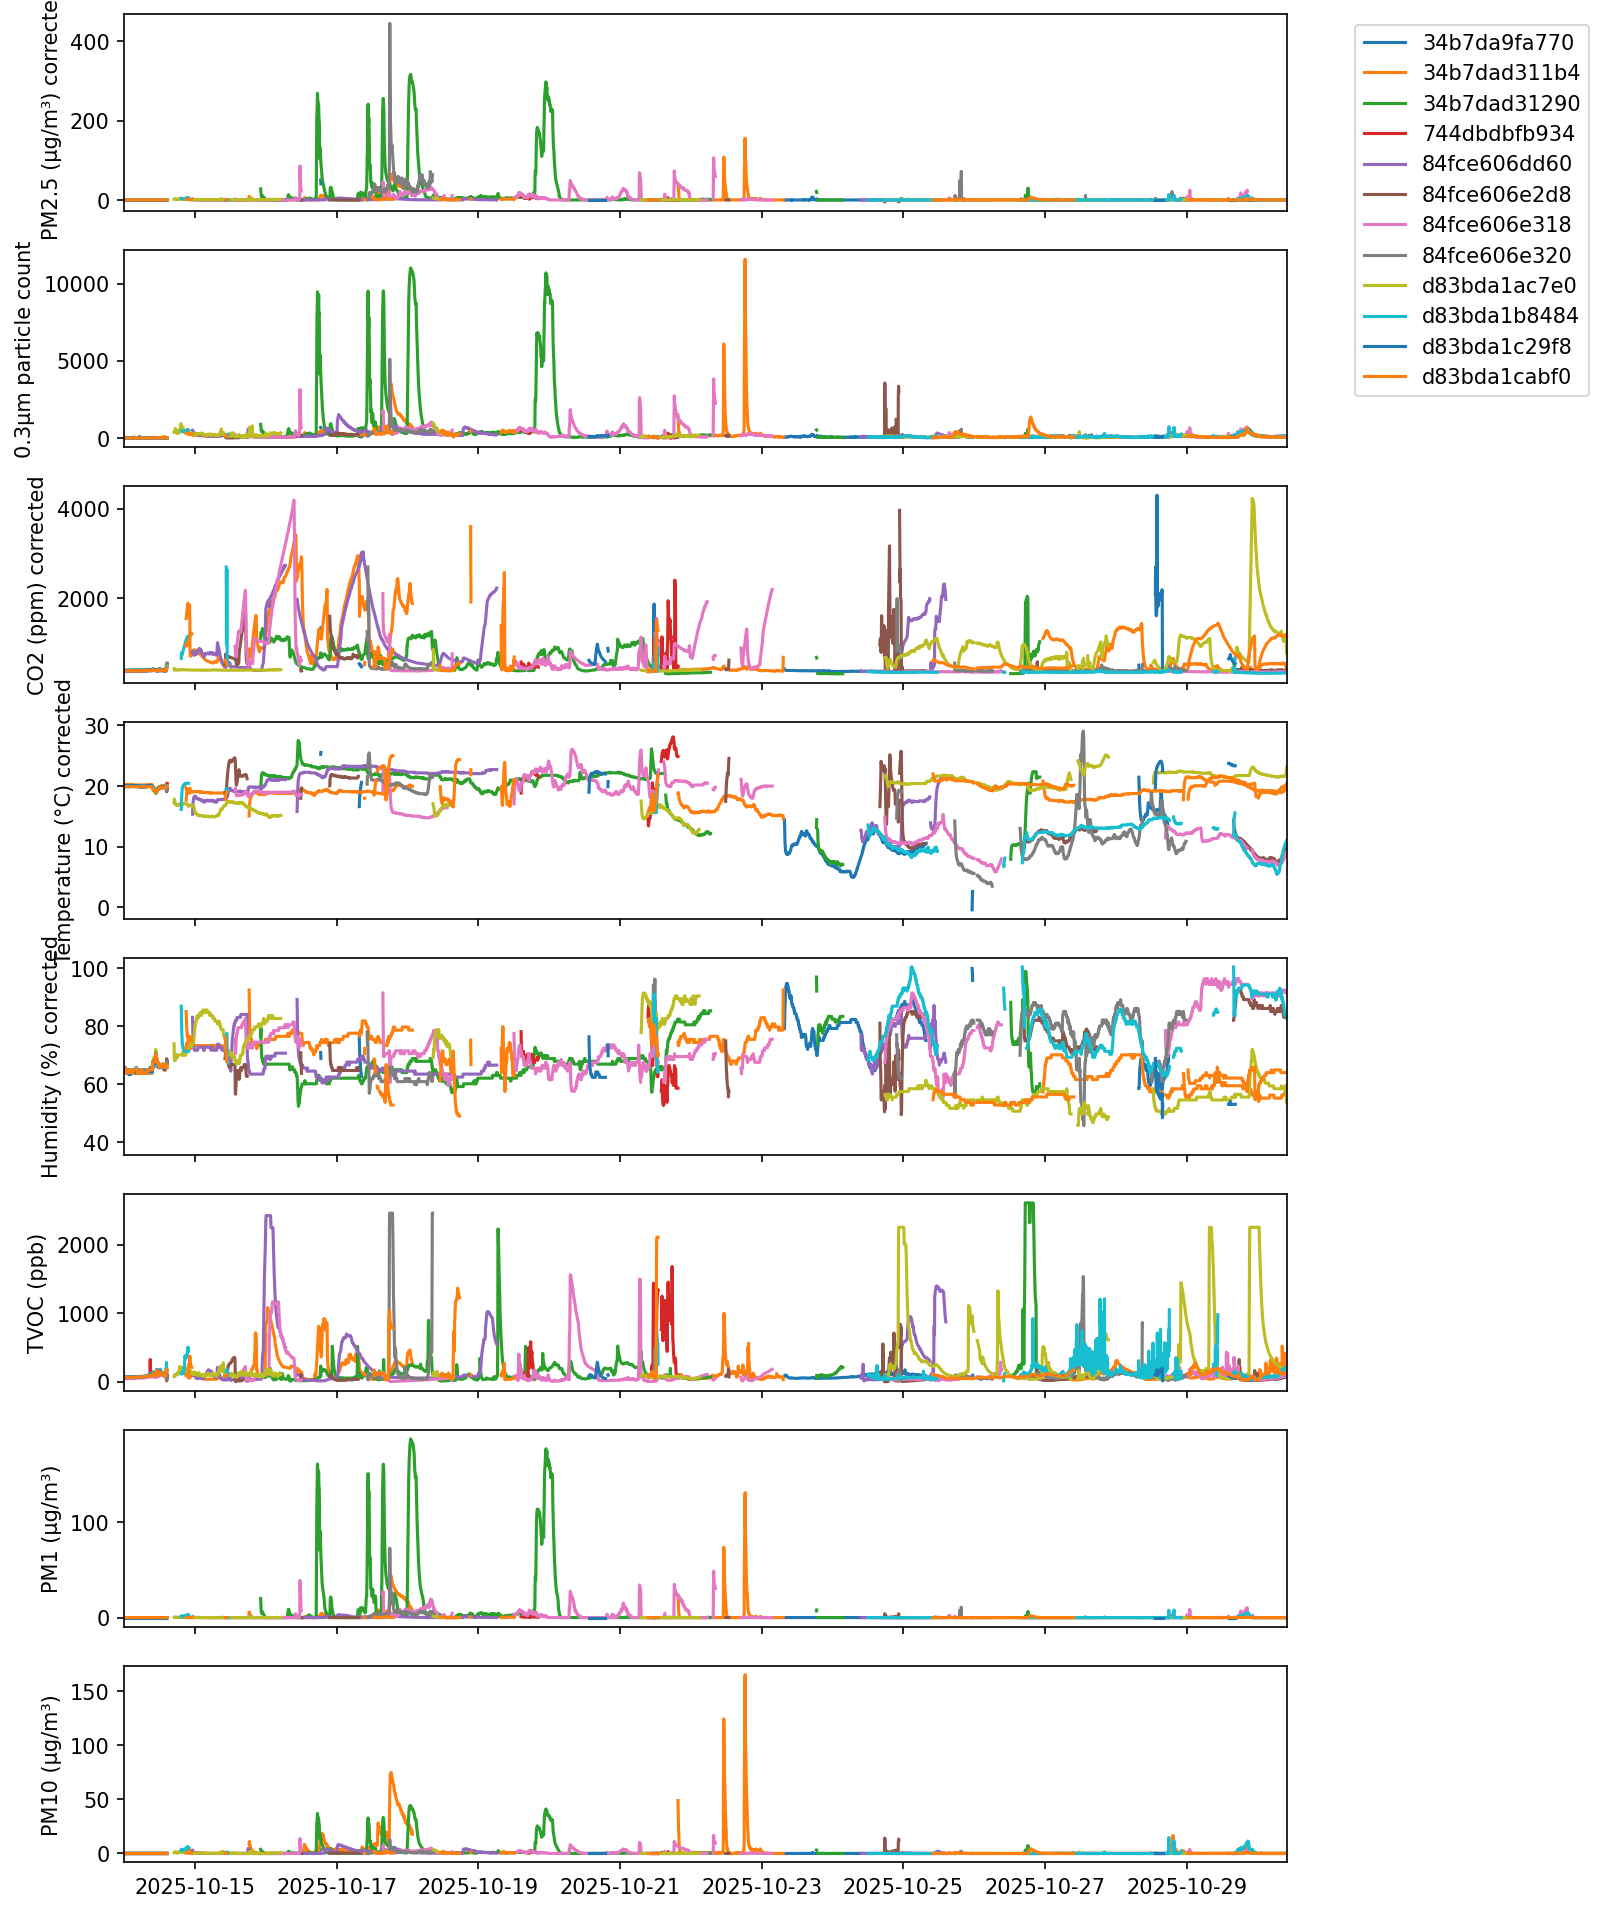

In [7]:
fig, axs = plt.subplots(nrows=len(vars), figsize=(10, 2*len(vars)), sharex=True)
for i, g in cal.groupby('Location Name'):
    g = g.sort_values('datetime').reset_index(drop=True)
    time_diff = g['datetime'].diff()
    mask = time_diff > pd.Timedelta(minutes=5)

    for j, var in enumerate(vars):
        plot_data = g[var].copy()
        plot_data[mask] = float('nan')

        axs[j].plot(g['datetime'], plot_data, label=i)

        axs[j].set_ylabel(var)
        
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[0].set_xlim(baseline_end, cal['datetime'].max())

In [11]:
dat['Location Name'].unique()

array(['34b7dad311b4', '84fce606e2d8', '84fce606e318', 'd83bda1cabf0',
       'd83bda1b8484', 'd83bda1ac7e0', 'd83bda1c29f8', '84fce606e320',
       '34b7da9fa770', '34b7dad31290', '84fce606dd60', '744dbdbfb934'],
      dtype=object)

(np.float64(20374.999988425927), np.float64(20391.413194444445))

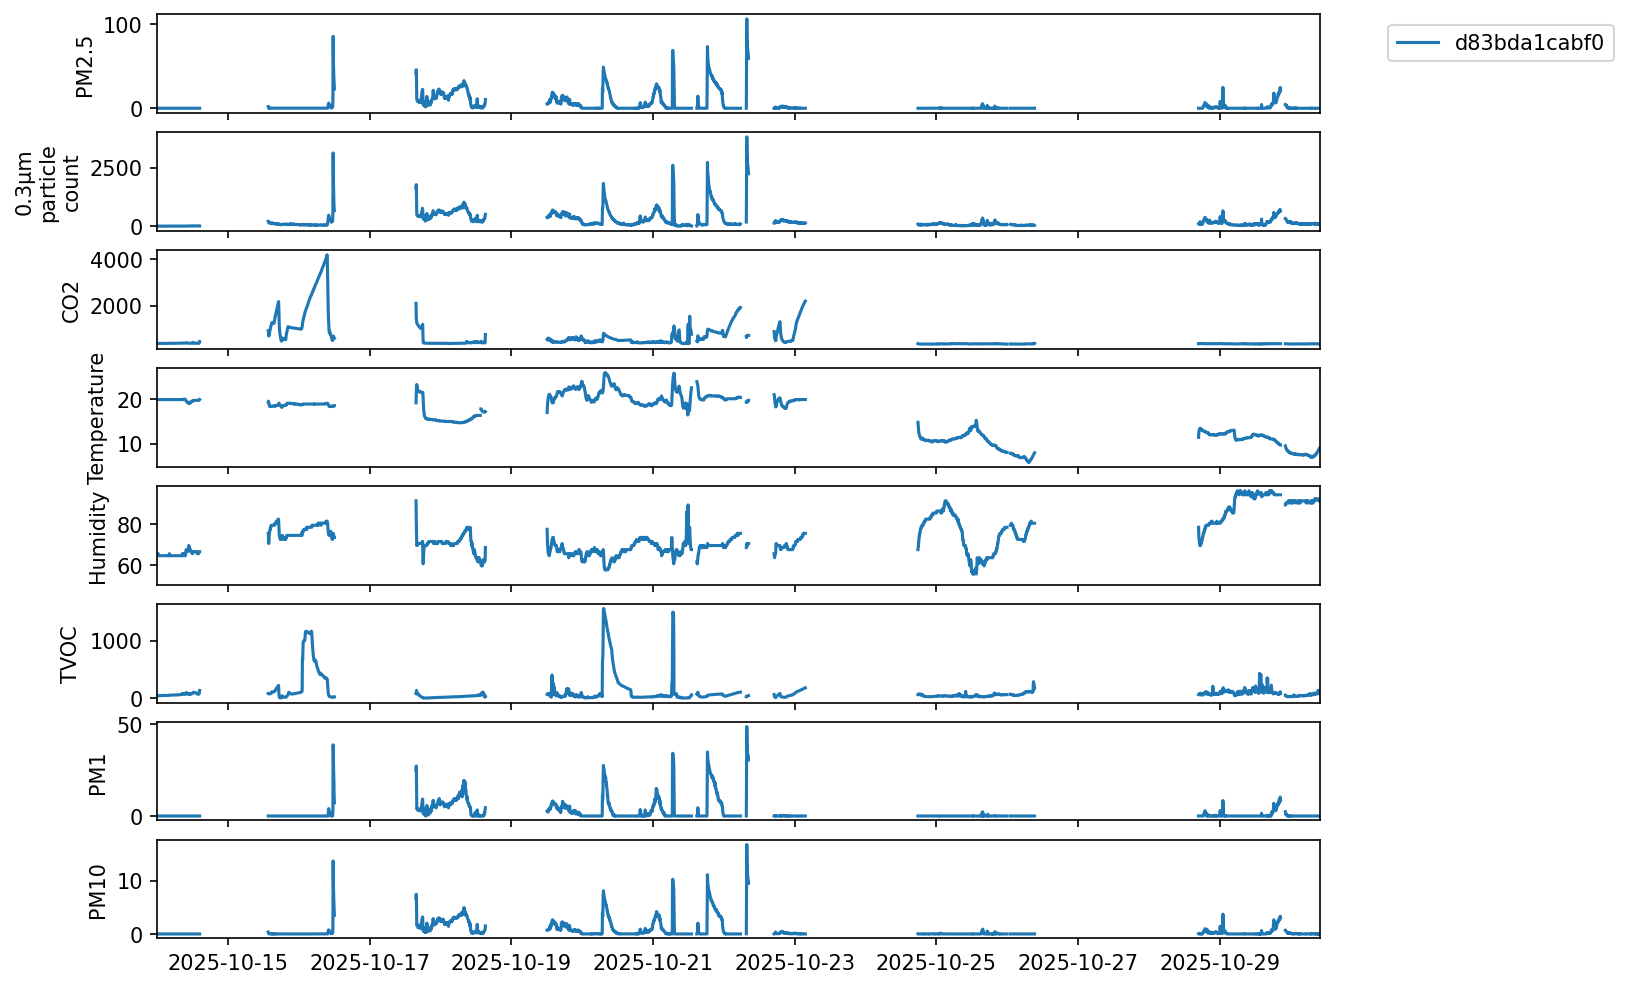

In [18]:
fig, axs = plt.subplots(nrows=len(vars), figsize=(10, 1*len(vars)), sharex=True)
# for i, g in cal.groupby('Location Name'):

g = cal[cal['Location Name']=='84fce606e318']
g = g.sort_values('datetime').reset_index(drop=True)
time_diff = g['datetime'].diff()
mask = time_diff > pd.Timedelta(minutes=5)

for j, var in enumerate(vars):
    plot_data = g[var].copy()
    plot_data[mask] = float('nan')

    axs[j].plot(g['datetime'], plot_data, label=i)

    axs[j].set_ylabel(var.split(' (')[0].replace(' ', '\n'))
        
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[0].set_xlim(baseline_end, cal['datetime'].max())

In [8]:
import seaborn as sns

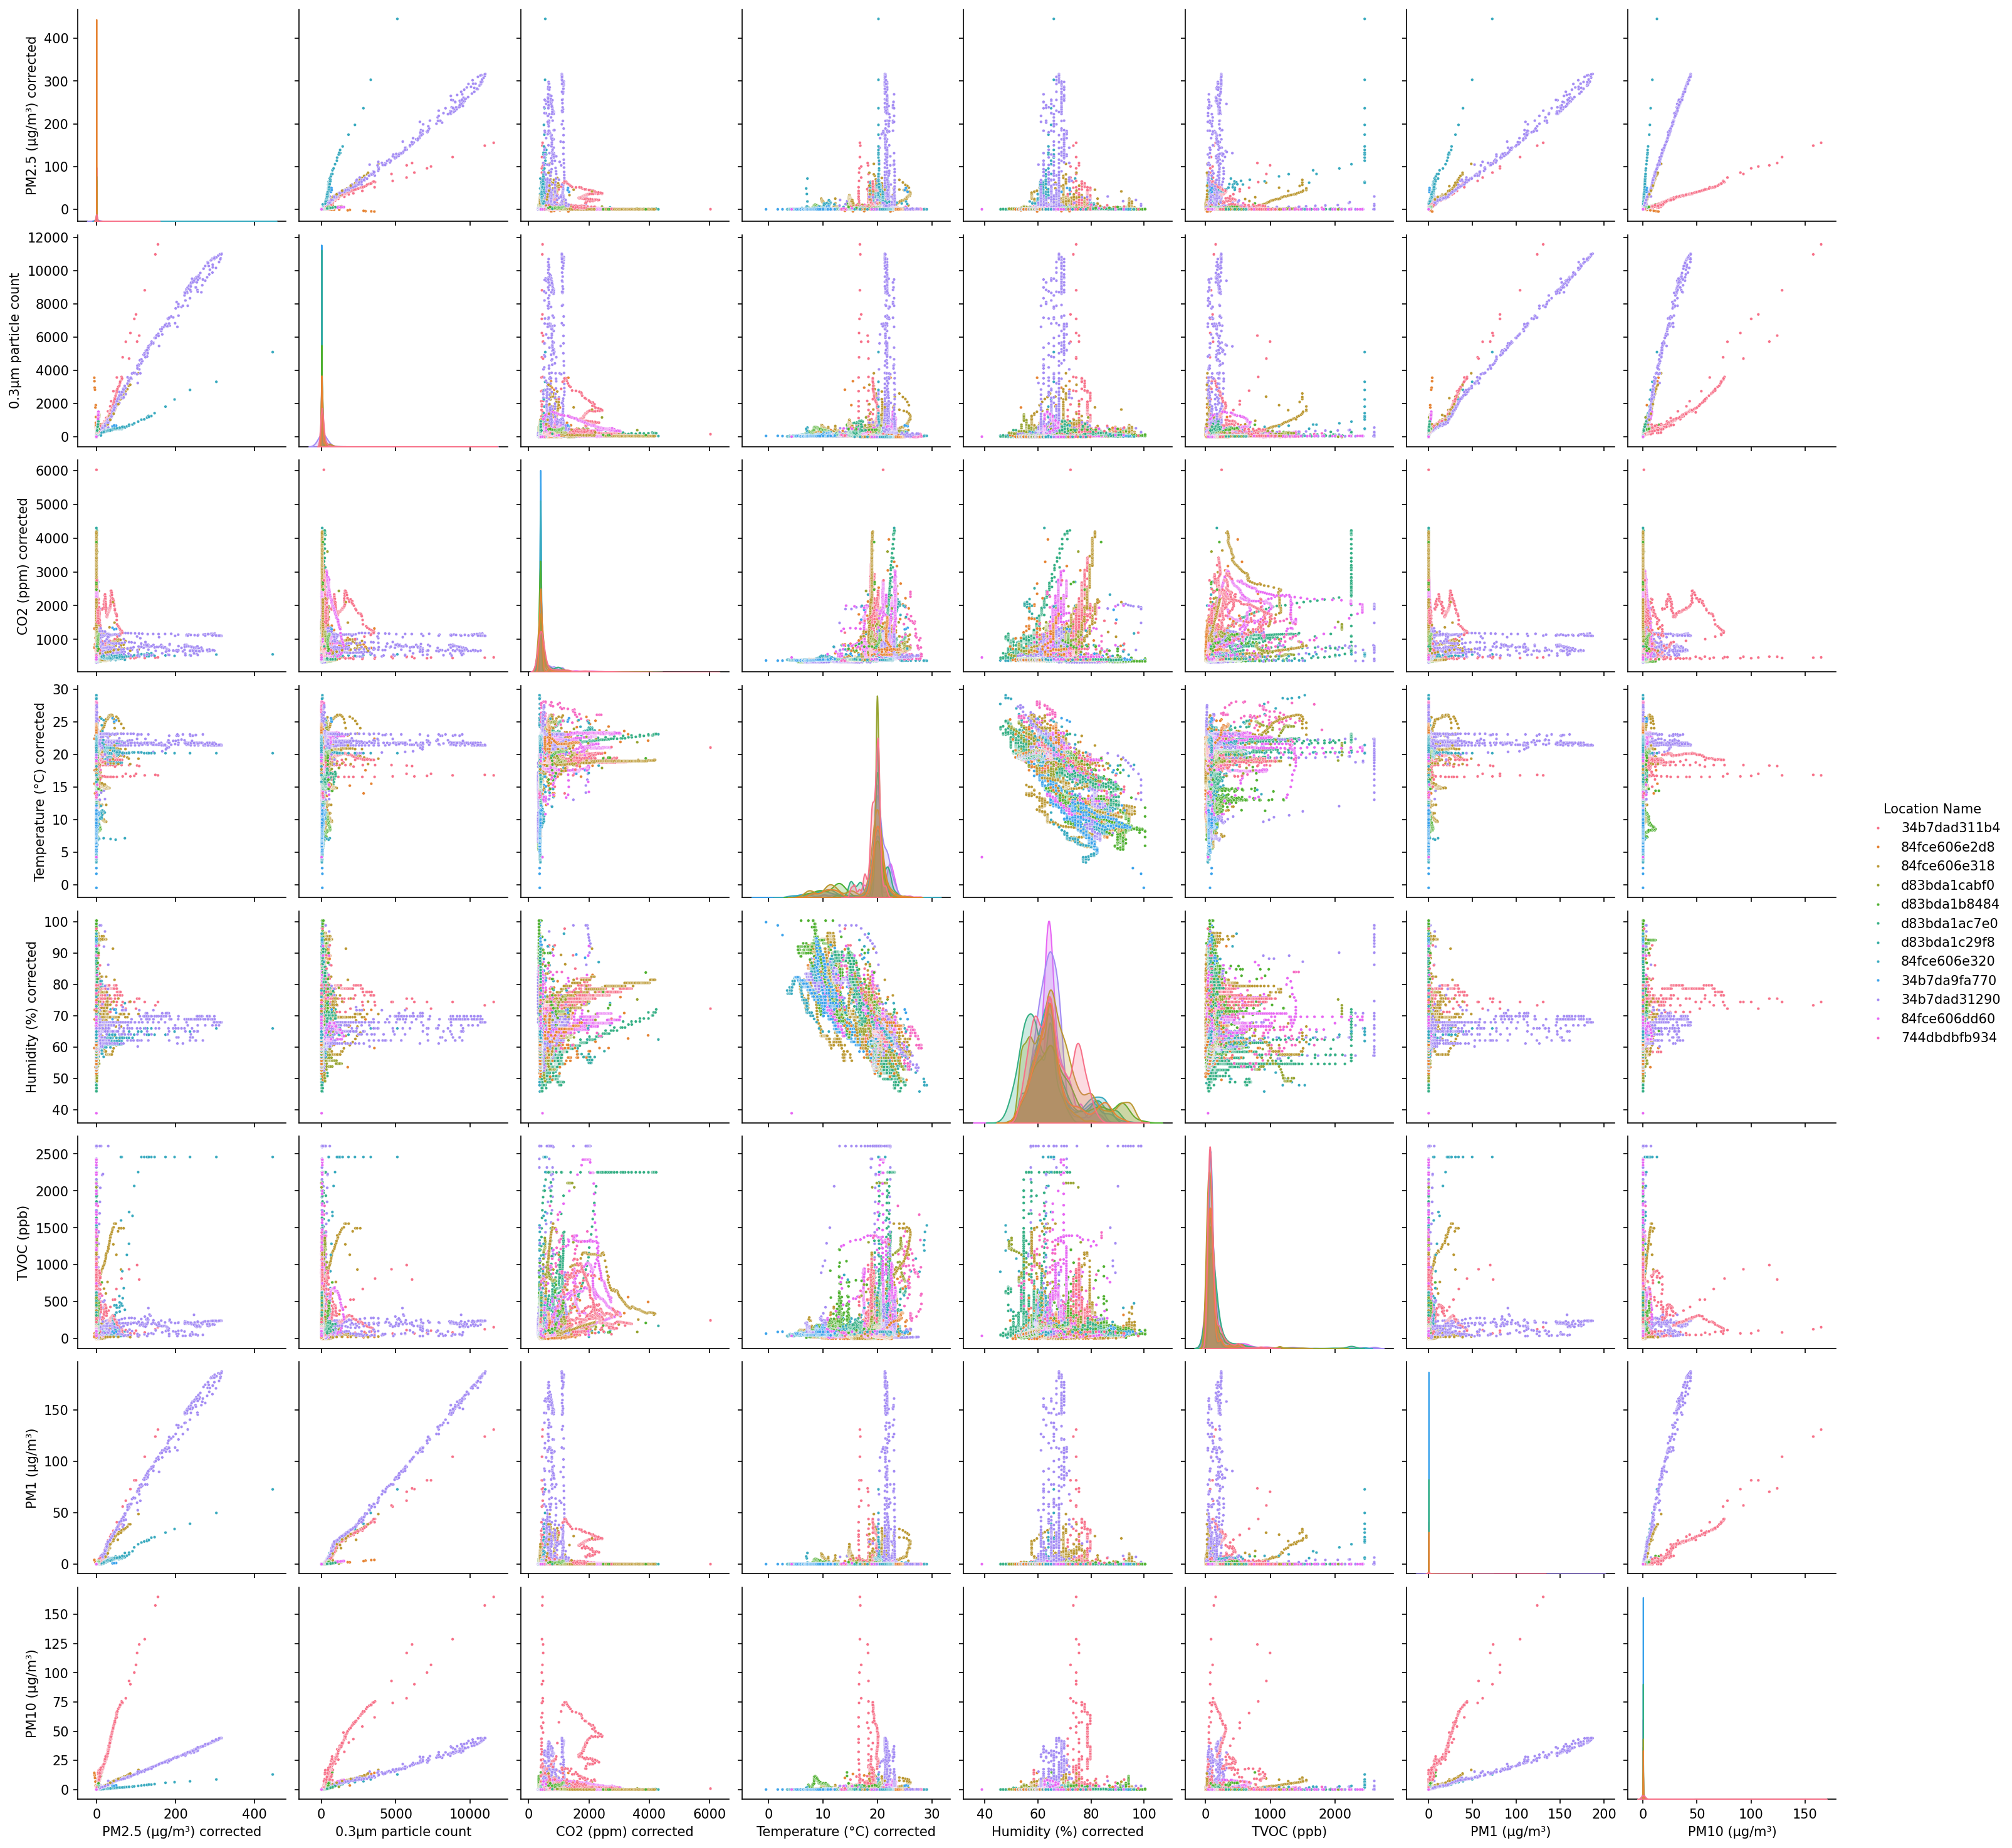

In [9]:
sns.pairplot(cal, vars=vars, hue='Location Name', plot_kws={'s':5})